# Metaheuristics Notebook - Telemetry Heart AI

In [11]:
%pip install langsmith -q 2>/dev/null
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path
sys.path.append('..')
ROOT = Path(os.path.abspath('')).resolve()
if (ROOT / 'notebooks').exists():
    ROOT = ROOT / '..'
DATA_DIR = ROOT / 'app' / 'data'
CHARTS_DIR = DATA_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
from app.services.genetic_engine import GeneticEngine
from app.services.pso_engine import PSOEngine

Note: you may need to restart the kernel to use updated packages.


In [12]:
# Load dataset
df = pd.read_csv(DATA_DIR / 'heart.csv')
X = df.drop('target', axis=1)
y = df['target']

In [13]:
# Genetic Algorithm
print("Running Genetic Algorithm...")
ga = GeneticEngine(n_features=13, population_size=50, generations=20)
ga_result = ga.run(X, y)
print(f"Selected features: {ga_result['feature_names']}")
print(f"N selected: {ga_result['n_selected']}")
print(f"Best fitness: {ga_result['best_fitness']:.4f}")

Running Genetic Algorithm...


/home/salazar/anaconda3/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/home/salazar/anaconda3/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Selected features: ['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'ca', 'thal']
N selected: 10
Best fitness: 0.9345


In [14]:
# PSO
print("\nRunning PSO...")
pso = PSOEngine(n_particles=30, n_iterations=30)
pso_result = pso.run(X, y)
print(f"Best params: {pso_result['best_params']}")
print(f"Best fitness: {pso_result['best_fitness']:.4f}")


Running PSO...
Best params: {'n_estimators': 154, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 3}
Best fitness: 0.9180


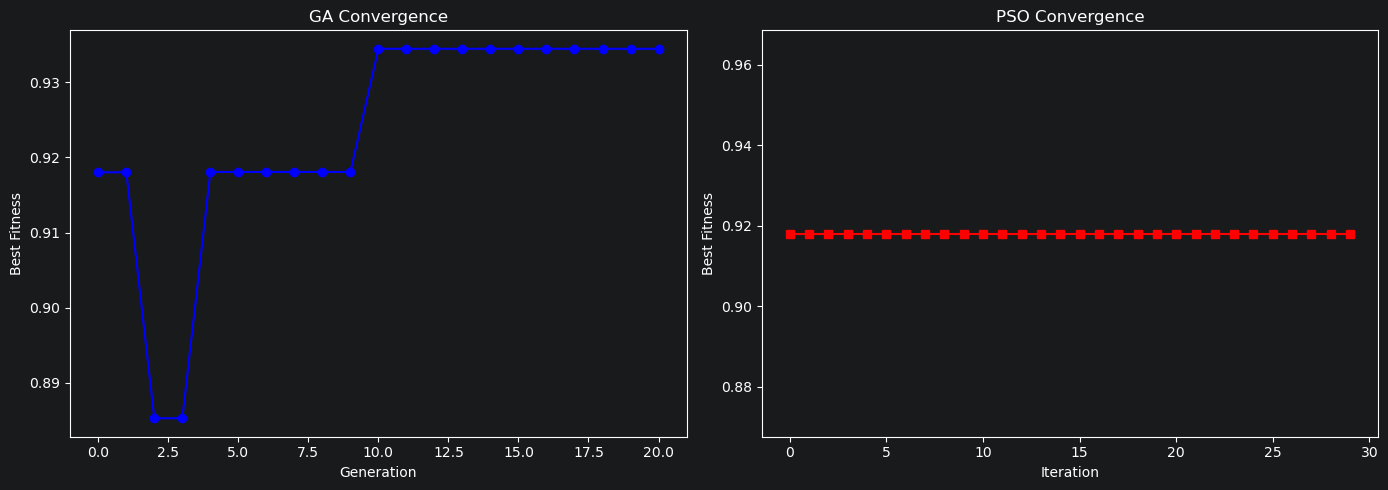

In [15]:
# Convergence plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GA convergence
if ga.history:
    gens = [log['gen'] for log in ga.history if 'gen' in log]
    max_fitness = [log['max'] for log in ga.history if 'max' in log]
    axes[0].plot(gens, max_fitness, 'b-o')
    axes[0].set_title('GA Convergence')
    axes[0].set_xlabel('Generation')
    axes[0].set_ylabel('Best Fitness')

# PSO convergence
if pso.history:
    iters = [h['iteration'] for h in pso.history]
    best_fits = [h['best_fitness'] for h in pso.history]
    axes[1].plot(iters, best_fits, 'r-s')
    axes[1].set_title('PSO Convergence')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Best Fitness')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'convergence.png')
plt.show()

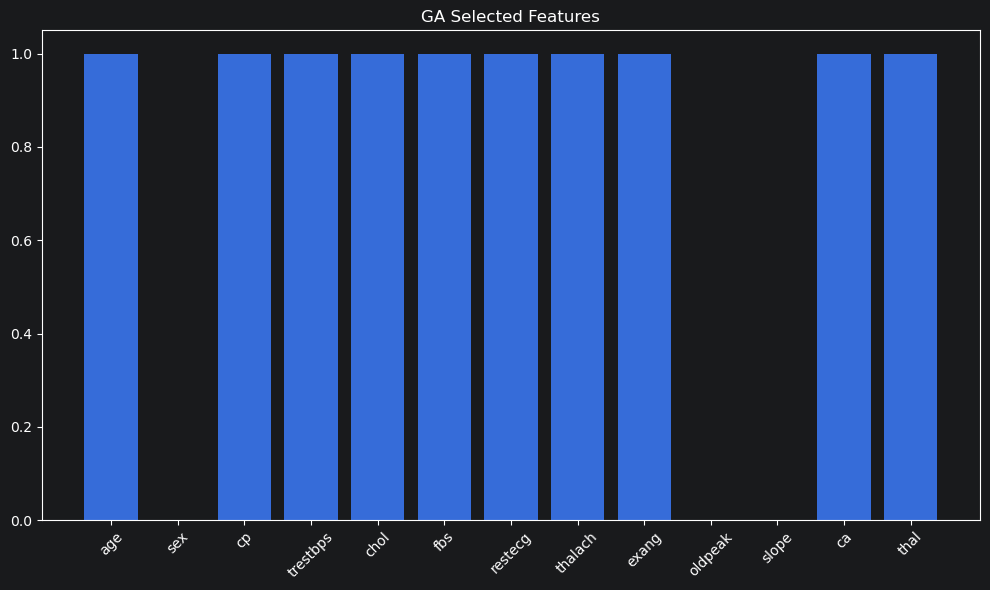

In [16]:
# Feature importance from GA
plt.figure(figsize=(10, 6))
selected = [1 if i in ga_result['selected_features'] else 0 for i in range(13)]
plt.bar(X.columns, selected)
plt.title('GA Selected Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ga_features.png')
plt.show()

In [17]:
print("Metaheuristics complete!")

Metaheuristics complete!
